# 05 · 完整流程:一次跑遍全部

这本把 **05_Shanghai Power to Form Students** 的整套流程**串成一条**,一次执行完:
数据 → 映射 → 只调高度天际线 → 权力算子四体制 → 3D 量体/OBJ → 生成 06 互动 html →(可选)换地方跑遍所有街道。

**所有图都会存到 `out/<slug>/Step_05/<时间戳>/`**;最后一格另把互动 html 出到 `06_AI Render Students/out/<slug>/canvas.html`。

> 原理拆解请看引擎代码(`engine/`);算子/体制定义在 `regimes.yaml` / `power_scenarios.yaml`。
> 这本只做一件事:**把整条流程全跑一遍、把产物全落盘。**

## 怎么执行
- 菜单 **Run → Run All Cells** 从头跑到尾;或点一格按 **Shift+Enter** 逐格跑。
- 换站点:改 `config.py` 的 `SLUG`,或在下面第一格后加一行 `config.SLUG = "waitan"`。
- 跑遍所有已缓存街道:把下面的 `RUN_ALL_SITES` 改成 `True`(较久)。

In [8]:
# 让 notebook 找到 engine 里的代码(这格不用改,直接执行)
import sys, os
sys.path.insert(0, os.path.abspath("engine"))
# 清掉旧的引擎模块缓存:改了 config/engine 后,重跑本格即刻生效(免重启内核)
for _m in [k for k in list(sys.modules) if k in ("config", "common", "operators", "measure")
           or k == "plots" or k.startswith("plots.") or k == "prints" or k.startswith("prints.")]:
    del sys.modules[_m]
import config, common as C, plots, prints
import operators as ops, measure as M
prints.ready()

# True = 最后一格把整套流程跑遍所有已缓存街道(较久);False = 只跑当前 SLUG。
# 批量跑全部:设环境变量 RUN_ALL_SITES=1 再执行(学生默认 False,不改这行也能全跑)。
RUN_ALL_SITES = os.environ.get("RUN_ALL_SITES", "0") == "1"
STAMP = plots.capture("05")     # 本册每张图都存到 out/<slug>/Step_05/<时间戳>/
print("输出时间戳:", STAMP, "→", "out/%s/Step_05/%s/" % (config.SLUG, STAMP))
print("RUN_ALL_SITES =", RUN_ALL_SITES)

引擎就绪 · 当前站点:陆家嘴街道(lujiazui)
输出时间戳: 20260702_091040 → out/lujiazui/Step_05/20260702_091040/
RUN_ALL_SITES = False


## 阶段 A · 数据 → 映射(合并 01 + 02)
读数据(有数据集就现建、否则用随包缓存)→ 看多源覆盖率 → 贴角色 → 反事实试改一条查表 → 画权力地图。

  建缓存 陆家嘴街道(lujiazui):3263 栋 → data\lujiazui\buildings.parquet
拼好了:3263 栋  ·  陆家嘴街道
覆盖率:
  euluc     93%
  function  42%

样例(前 8 栋的多源列):
    height_m   euluc  function aoi_type2 aoi_type1
0  14.862233  商务办公用地       NaN        楼宇      商务住宅
1  14.217366     NaN       NaN       NaN       NaN
2  45.997633  商业服务用地       NaN        楼宇      商务住宅
3  63.896900  商务办公用地       NaN      宾馆酒店      住宿服务
4  90.024500  商务办公用地  Business      宾馆酒店      住宿服务
5  89.570900  商务办公用地  Business      宾馆酒店      住宿服务
6  21.803766  商务办公用地       NaN        楼宇      商务住宅
7  83.906233  商务办公用地    Office        楼宇      商务住宅
各角色栋数: {'resident': 1797, 'developer': 838, 'state': 511, 'unknown': 117}
把『商务办公用地』从 developer 改判给 state:
  改前: {'resident': 1797, 'developer': 838, 'state': 511, 'unknown': 117}
  改后: {'resident': 1797, 'state': 1214, 'developer': 135, 'unknown': 117}
  -> saved out\lujiazui\Step_05\20260702_091040\01_data_overview.png


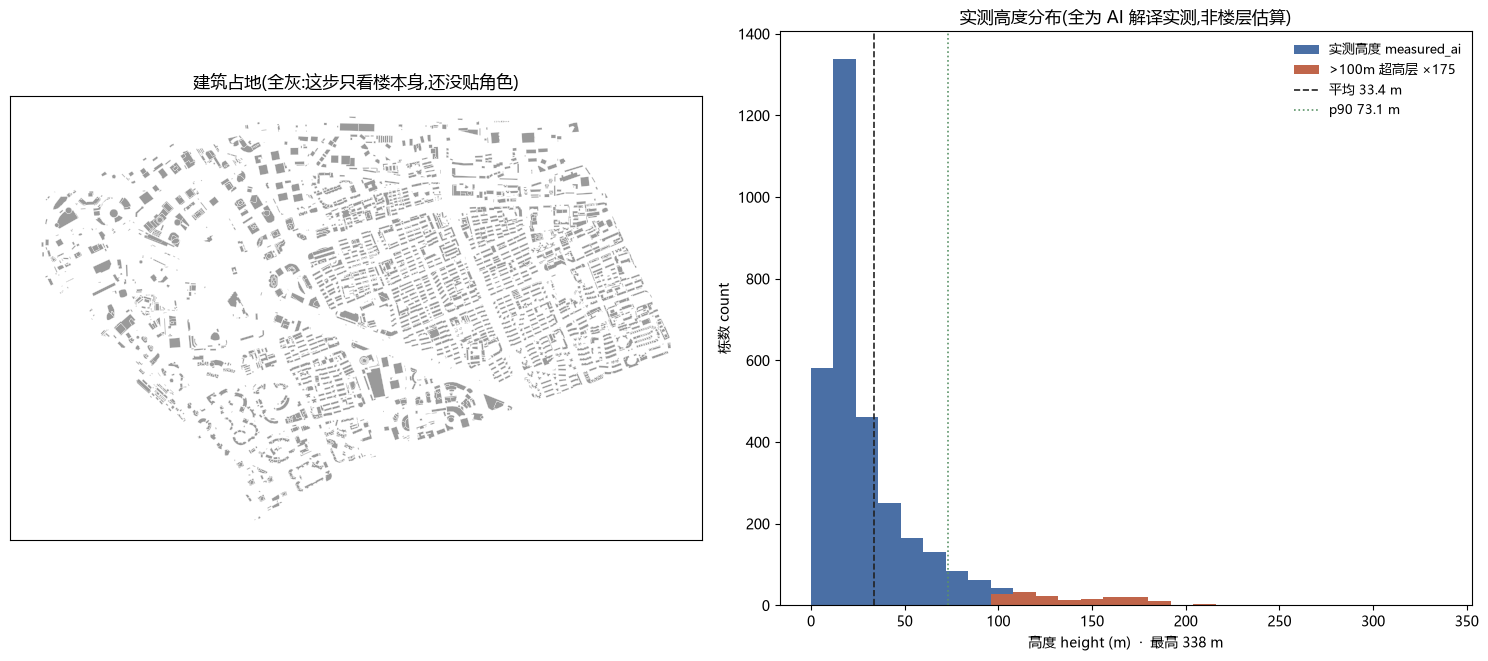

  -> saved out\lujiazui\Step_05\20260702_091040\02_power_map.png


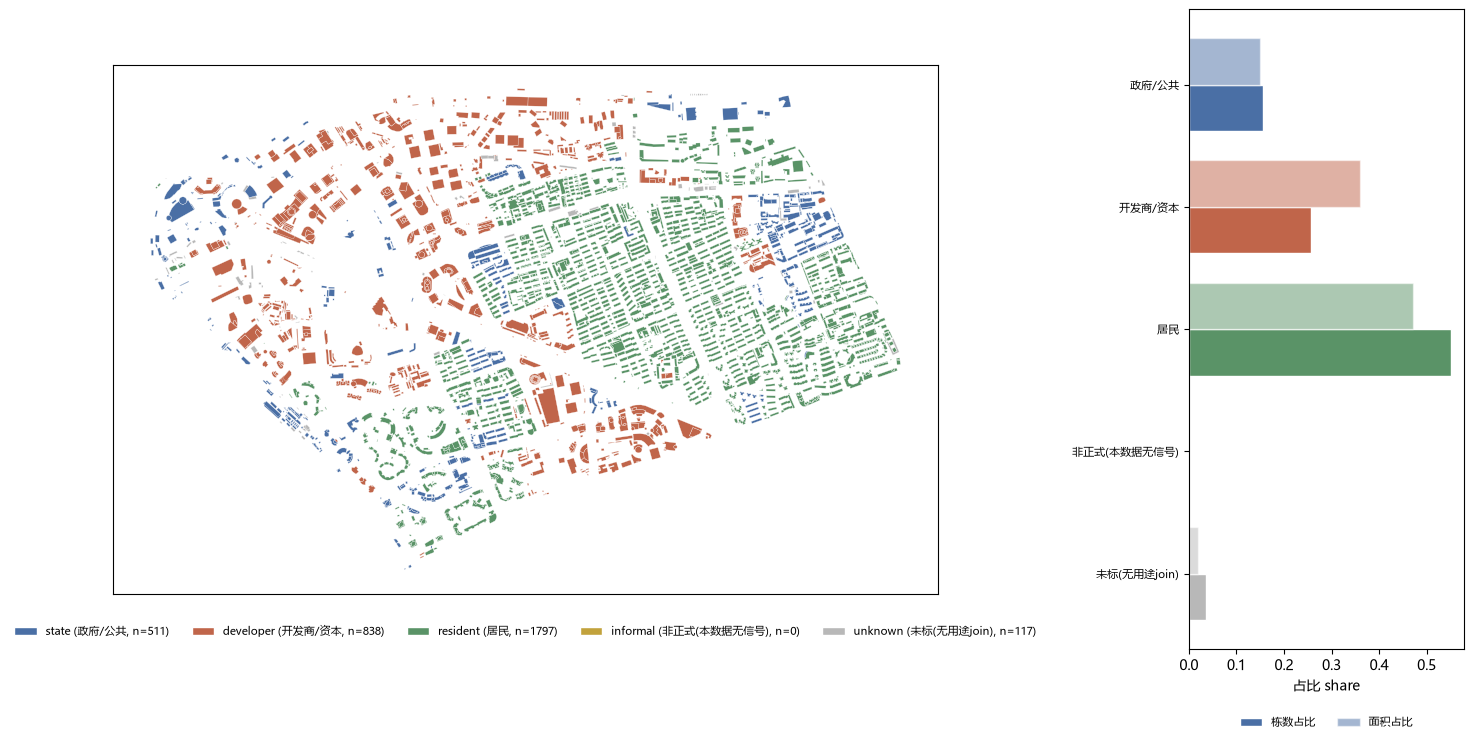

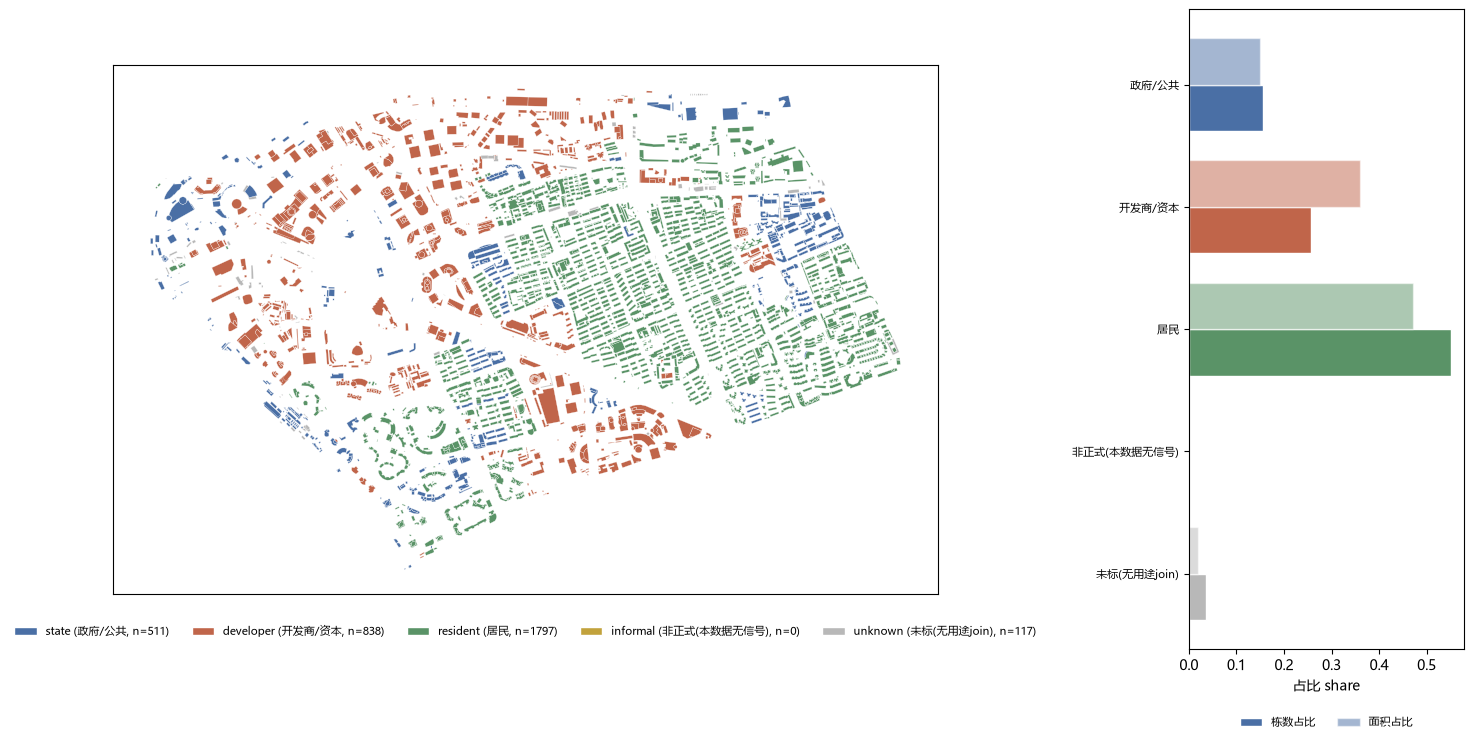

In [9]:
df, source = C.build_or_load(config.SLUG)     # 有数据集就现建、否则用随包缓存(分支在 build_or_load 里)
prints.prepared(df, source)
prints.coverage(df)                           # 多源覆盖率
df = C.assign_all(df)                          # 贴角色 stakeholder(读 shanghai_lookup.yaml)
prints.stakeholders(df)
res = C.counterfactual(df, frm="developer", to="state")   # 反事实(不动文件、内存里试):看分布怎么变
prints.counterfactual(res)
plots.data_overview(df)                        # 原料:footprint + 实测高度分布
plots.power_map(df)                            # 权力地图:按角色著色

## 阶段 B · 只调高度,看天际线(03 主册)
锁死 footprint 与角色,只放开高度。套 4 个情景横向比——差异完全来自权力配置。

In [ ]:
try:
    plots.satellite_figureground(df)     # 需联网;失败自动跳过
except Exception as e:
    prints.skipped("卫星", e)
DAPUQIAO_SCENARIO_NAMES = [
    "current",
    "tourism_capture",
    "everyday_life_first",
    "heritage_micro_economy",
    "negotiated_24h_alley",
]
all_scen = C.load_scenarios()
scen = {name: all_scen[name] for name in DAPUQIAO_SCENARIO_NAMES}
prints.scenarios(scen)
plots.policy_heatmap(scen)      # 红=拔高 / 蓝=压低 / 白=照旧
SCEN_NAMES = DAPUQIAO_SCENARIO_NAMES
heights = {n: (C.scenario_heights(df, scen[n]) if n != "current" else df["height_m"]) for n in SCEN_NAMES}
plots.skyline_panels(df, heights, names=SCEN_NAMES)    # 同色阶可横比
plots.metrics(df, heights, names=SCEN_NAMES)           # 总GFA / 平均高 / 最高 / 各角色平均高


## 阶段 C · 权力算子 → 四种形态(04 进阶)
权力现在能改**形态语法**:拆板成塔 / 细粒自建 / 向权力重心收拢 / 放大。再把操作串成 4 种体制横比 + 量化特征。

In [ ]:
recs = C.to_recs(df)
prints.op_list(recs)
b = ops.freeze(recs, who=["state"])                                   # 先锁定政府公共
a = ops.split_to_towers(b, target=["resident", "developer"], above_m2=1500, k=3)
plots.operator_demo(b, a, "拆板成塔 split_to_towers(k=3)")
a2 = ops.infill(b, target=["resident", "developer"], cell_m2=120, min_h=6, max_h=21)
plots.operator_demo(b, a2, "居民自建 infill(cell≈120㎡)", color="h")
ac = ops.concentrate(b)
plots.operator_demo(b, ac, "中央集权 concentrate(向权力重心收拢)", color="h")
tagged = ops.freeze_tags(recs, tags=["heritage", "residential_core", "emergency_access"])
plots.operator_demo(recs, tagged, "freeze_tags(保护历史/居住/消防)", color="sh")

micro = ops.micro_lease(tagged, target=["developer"], above_m2=500, cell_m2=80,
                       affordable_ratio=0.35, local_service_ratio=0.20, culture_ratio=0.15,
                       min_h=6, max_h=18, seed=42)
plots.operator_demo(tagged, micro, "micro_lease(大商业拆成微租赁单元)", color="sh")
frontage = ops.frontage_quota(micro, primary_routes="tourist_spine", frontage_buffer_m=8,
                            max_tourism_ratio=0.45, min_local_service_ratio=0.15,
                            min_micro_shop_ratio=0.25, min_culture_ratio=0.15, seed=42)
plots.operator_demo(micro, frontage, "frontage_quota(游客主线界面配额)", color="sh")

valved = ops.crowd_valve(frontage, route="tourist_spine", crowd_threshold=0.75,
                         one_way_links=True, protect_tags=["resident_gate", "emergency_access"],
                         relief_nodes=3)
plots.operator_demo(frontage, valved, "crowd_valve(高峰客流阀门)", color="h")

night = ops.night_reversion(valved, start_hour=22, quiet_buffer_m=10,
                            commercial_shutdown_ratio=0.60,
                            protect_tags=["residential_core", "resident_gate"])
plots.operator_demo(valved, night, "night_reversion(22点后夜间归还)", color="h")
DAPUQIAO_REGIME_NAMES = [
    "tourism_capture",
    "everyday_life_first",
    "heritage_micro_economy",
    "negotiated_24h_alley",
]
all_regs = ops.load_regimes()
regs = {name: all_regs[name] for name in DAPUQIAO_REGIME_NAMES}
prints.regimes(regs)
after = {n: ops.apply_regime(recs, regs[n]) for n in regs}
labels = {n: regs[n]["label"] for n in regs}
plots.regime_compare(recs, after, labels=labels)
rows, _ = M.compare(recs, after, config.SLUG)
plots.feature_bars(rows, labels={"current": "现状", **labels})
prints.features(rows, {"current": "现状", **labels})


## 阶段 D · 3D 量体 + OBJ
把真实 footprint 按高度挤成 3D。OBJ 写到 `out/<slug>/`,并复制一份进本次 `Step_05/<时间戳>/`。

In [ ]:
import shutil
plots.city_3d(df, top=120)                          # current 3D preview
negotiated = df.copy()
negotiated["height_m"] = heights["negotiated_24h_alley"].values
plots.city_3d(negotiated, top=120)                  # negotiated_24h_alley 3D preview
objp, nv, nf = C.export_obj(df, config.SLUG)         # export all buildings to OBJ

dst = C.OUT / config.SLUG / "Step_05" / STAMP / objp.name
dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copyfile(objp, dst)
prints.obj_written(objp, nv, nf)
print("OBJ copied to:", dst.relative_to(C.ROOT))


## 阶段 E(可选)· 换地方:跑遍所有已缓存街道(05)
把顶部 `RUN_ALL_SITES` 改成 `True` 才会跑。每个街道各自输出到自己的 `out/<slug>/Step_05/<时间戳>/`。
这正是进阶册的点题:**权力的几何逻辑对基底不变,但结果在乎基底。**

In [ ]:
def run_site(slug):
    """对一个街道跑一遍精简全流程(权力地图 + 天际线 + 四体制 + OBJ)。"""
    plots.capture("05")                                      # 每站各开一个时间戳夹、序号归零
    d = C.assign_all(C.current_buildings(slug))
    plots.power_map(d)
    sc = C.load_scenarios()
    hs = {n: (C.scenario_heights(d, sc[n]) if n != "current" else d["height_m"])
          for n in DAPUQIAO_SCENARIO_NAMES}
    plots.skyline_panels(d, hs)
    r = C.to_recs(d); rg = ops.load_regimes()
    selected_rg = {n: rg[n] for n in DAPUQIAO_REGIME_NAMES if n in rg}
    af = {n: ops.apply_regime(r, selected_rg[n]) for n in selected_rg}
    plots.regime_compare(r, af, labels={n: selected_rg[n]["label"] for n in selected_rg})
    C.export_obj(d, slug)
    print("  完成", slug)

if RUN_ALL_SITES:
    cached = sorted(p.name for p in C.DATA.iterdir() if (p / "buildings.parquet").exists())
    print("已缓存街道:", cached)
    for s in cached:
        config.SLUG = s
        print("==", s, "==")
        run_site(s)
    print("全部完成。每站产物在 out/<slug>/Step_05/<时间戳>/")
else:
    print("RUN_ALL_SITES = False → 只跑了当前站点。要跑遍所有街道,把顶部改成 True 再 Run All。")

## 阶段 F · 生成 06 的 html(canvas.html + report.html)并回链 05 结果
把本站点体块交给隔壁 `06_AI Render Students`,一次产出**两份自含 html**:
- **`06/out/<slug>/canvas.html`** — 互动画布(Three.js 内联):卫星地面 + 各权力体制体块,拖拽找角度、导出 massing / ControlNet 条件图。
- **`06/out/<slug>/report.html`** — AI 渲染报告:每体制 结构层(体块) ↔ 表面层(AI 渲染) ↔ 提示词三层 + 过渡动画,聚合成一页。

并在本次 **`out/<slug>/Step_05/<时间戳>/index.html`** 写一张「05 结果页」:列出本次跑的图,底部一键跳到上面两份 06 html。三者互链:

```
05 Step_05/<时间戳>/index.html ──▶ 06 canvas.html ⇄ 06 report.html
```

> 这是本工作坊的 html 看图入口(原 05 web 报告已移除)。首次需装 06 依赖:`pip install -r "06_AI Render Students/engine/requirements.txt"`。
> `RUN_ALL_SITES=True` 时,对所有已缓存街道各出一套(canvas + report + 结果页)。


In [14]:
# 把本站体块接到 06:出 canvas.html + report.html,并在 05 结果目录写「前向链接页」
# 链路:05 Step_05/<时间戳>/index.html  →  06 canvas.html  ⇄  06 report.html
# 06 唯一入口 = run.py(设定都在 06 的 config.yaml;程式在 06/engine)
import subprocess, sys
R06 = C.ROOT.parent / "06_AI Render Students"
sites = ([p.name for p in C.DATA.iterdir() if (p / "buildings.parquet").exists()]
         if RUN_ALL_SITES else [config.SLUG])
for s in sites:
    print("== 06 产出:", s, "==")
    # run.py <slug> = 该站 canvas.html + report.html(两者互链)
    subprocess.run([sys.executable, "run.py", s], cwd=str(R06))
    # 05 结果页:取本站最新 Step_05/<时间戳>/,写 index.html 前向链到 06 canvas / report
    step_root = C.OUT / s / "Step_05"
    stamps = sorted(p for p in step_root.iterdir() if p.is_dir()) if step_root.exists() else []
    if stamps:
        subprocess.run([sys.executable, "run.py", "bridge", s, str(stamps[-1])], cwd=str(R06))
        print("  ↪ 05 结果页:", (stamps[-1] / "index.html").relative_to(C.ROOT))
    cv = R06 / "out" / s / "canvas.html"
    print("  ✅ " + str(cv) if cv.exists() else
          "  ⚠ 未生成 —— 请先装 06 依赖:pip install -r \"06_AI Render Students/engine/requirements.txt\"")
print("\n入口:打开 05 结果页 Step_05/<时间戳>/index.html → 一键跳 06 canvas.html / report.html(canvas 与 report 互链)。")

== 06 产出: lujiazui ==
  ↪ 05 结果页: out\lujiazui\Step_05\20260702_091040\index.html
  ✅ C:\baidunetdiskdownload\power_to_form\DF26_ws18\06_AI Render Students\out\lujiazui\canvas.html

入口:打开 05 结果页 Step_05/<时间戳>/index.html → 一键跳 06 canvas.html / report.html(canvas 与 report 互链)。
